# FFLogs 样本探索

探索 `statistics-samples:encounter:{id}` KV 中保存的原始样本。

## 数据准备

```bash
# 在项目根目录（或 analysis/ 目录）运行：
./analysis/scripts/pull_samples.sh          # 拉所有
./analysis/scripts/pull_samples.sh 93 97    # 拉指定 encounter
./analysis/scripts/pull_samples.sh --local  # 拉本地 KV
```

## 代码组织

- **`analysis/hb.py`** — 加载、转换、统计的可复用函数
- **本 notebook** — 只做探索、画图、写结论

In [1]:
import sys
from pathlib import Path

# 让 notebook 能 import 到 analysis/hb.py
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import hb

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

## 1. 加载样本

In [2]:
ENCOUNTER_ID = 101  # 改成你拉下来的 id

raw = hb.load_samples(ENCOUNTER_ID)
frames = hb.load_frames(ENCOUNTER_ID)
damage, heal, shield, maxhp = frames["damage"], frames["heal"], frames["shield"], frames["maxhp"]

print("encounterId:", raw["encounterId"])
print("updatedAt:", raw.get("updatedAt"))
print()
print(f"damage : {damage.shape[0]:>6} 条样本, {damage['ability_id'].nunique()} 个技能")
print(f"heal   : {heal.shape[0]:>6} 条样本, {heal['ability_id'].nunique()} 个技能")
print(f"shield : {shield.shape[0]:>6} 条样本, {shield['status_id'].nunique()} 个状态")
print(f"maxhp  : {maxhp.shape[0]:>6} 条样本, {maxhp['job'].nunique()} 个职业")

encounterId: 101
updatedAt: 2026-04-09T00:01:11.729Z

damage :  14429 条样本, 54 个技能
heal   :  40553 条样本, 112 个技能
shield :  10760 条样本, 29 个状态
maxhp  :  10500 条样本, 21 个职业


## 2. Reservoir 填充情况

检查每个 ability 的样本是否填满 MAX_SAMPLES=500。填不满的说明该技能较少见，或者累计数据还没跑够。

In [3]:
hb.sample_coverage(damage, "ability_id").head(20)

,count,full,fill_rate
ability_id,,,
1002942,500,True,1
45942,500,True,1
48039,500,True,1
47235,500,True,1
47048,500,True,1
45985,500,True,1
45983,500,True,1
45982,500,True,1
45979,500,True,1


## 3. 按技能/职业聚合统计

`cv`（变异系数 = std/mean）越大说明分布越分散，p50 的代表性越弱，建议看直方图。

In [4]:
hb.summary(damage, "ability_id", "damage")

,count,min,p50,p90,max,mean,std,cv
ability_id,,,,,,,,
46855,5,9999999,"9,999,999","9,999,999",9999999,"9,999,999",0,0
45927,2,9999999,"9,999,999","9,999,999",9999999,"9,999,999",0,0
45951,500,263762,"404,422","429,553",630022,"401,831","32,458",0
47235,500,116276,"380,238","400,998",605657,"381,565","46,875",0
16152,52,9811,"259,994","380,838",390055,"242,421","101,004",0
45936,500,84054,"198,219","218,533",229097,"184,968","34,456",0
45935,500,89239,"189,559","210,621",217068,"178,604","32,617",0
45933,500,113100,"187,804","204,125",275666,"176,010","32,256",0
45926,500,70101,"172,371","191,667",293013,"161,097","32,133",0


In [5]:
hb.summary(heal, "ability_id", "heal")

,count,min,p50,p90,max,mean,std,cv
ability_id,,,,,,,,
1000811,203,13611,"94,044","152,510",178392,"91,098","39,700",0
3610,2,73784,"91,103","104,958",108422,"91,103","24,493",0
1001220,156,64290,"91,072","127,450",151367,"94,102","25,057",0
1003902,449,62920,"83,810","130,016",152257,"92,201","21,301",0
3552,229,65080,"80,139","124,277",191105,"90,427","24,237",0
...,...,...,...,...,...,...,...,...
1000084,500,790,"4,392","11,939",47951,"5,515","4,894",1
1002598,500,1284,"3,282","4,254",5785,"3,483",550,0
1302,500,19,"2,264","3,251",3903,"2,422",589,0


In [6]:
hb.summary(shield, "status_id", "shield")

,count,min,p50,p90,max,mean,std,cv
status_id,,,,,,,,
811,114,2650,"231,937","1,836,123",2122481,"794,693","805,105",1
3830,500,925,"65,745","79,397",88145,"61,380","18,288",0
168,106,375,"61,056","61,571",61598,"48,297","18,393",0
1918,500,916,"58,078","89,956",165452,"56,069","30,094",1
2607,25,8479,"57,815","72,558",73703,"53,153","18,236",0
1178,500,934,"56,654","81,283",89411,"55,868","24,516",0
488,128,429,"45,315","45,333",45333,"40,151","12,585",0
1218,500,27,"44,151","50,217",67428,"39,217","14,045",0
2609,500,40,"44,112","71,375",92327,"41,368","19,688",0


In [7]:
hb.summary(maxhp, "job", "max_hp")

,count,min,p50,p90,max,mean,std,cv
job,,,,,,,,
WAR,500,293814,"325,333","325,419",390502,"329,627","19,128",0
DRK,500,311631,"325,133","325,219",325219,"322,963","3,900",0
GNB,500,303418,"325,133","325,262",429175,"327,980","20,211",0
PLD,500,297484,"325,090","325,219",357599,"324,203","4,377",0
DRG,500,218641,"227,520","227,671",227671,"227,180","1,103",0
RPR,500,225865,"227,520","227,520",227641,"227,060",740,0
MNK,500,225815,"226,688","226,778",226778,"226,694",57,0
SAM,500,207896,"226,648","226,708",226708,"224,326","4,314",0
NIN,500,225494,"226,608","226,668",226668,"226,513",308,0


## 4. 分布可视化

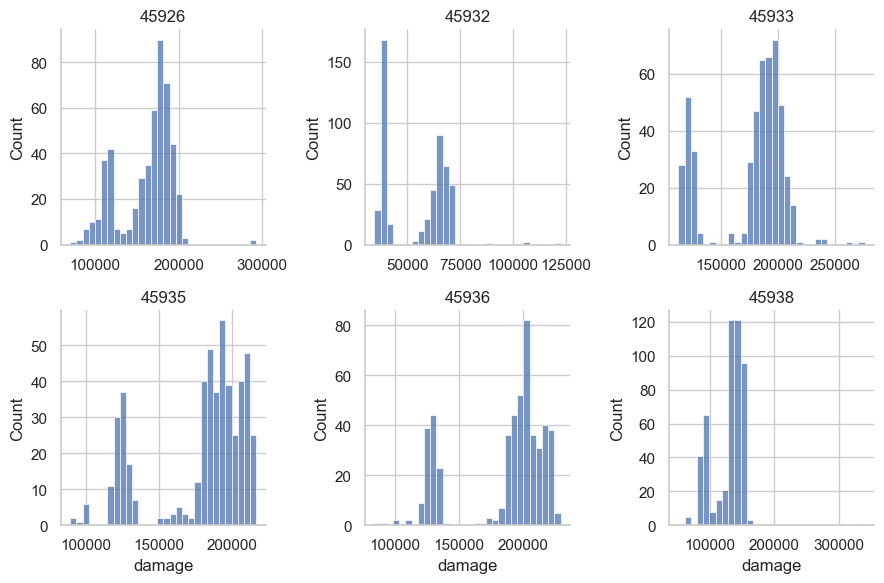

In [8]:
def plot_top_histograms(df: pd.DataFrame, group_col: str, value_col: str, top_n: int = 6):
    top = df[group_col].value_counts().head(top_n).index
    subset = df[df[group_col].isin(top)]
    g = sns.FacetGrid(subset, col=group_col, col_wrap=3, height=3, sharex=False, sharey=False)
    g.map_dataframe(sns.histplot, x=value_col, bins=30)
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()

plot_top_histograms(damage, "ability_id", "damage")

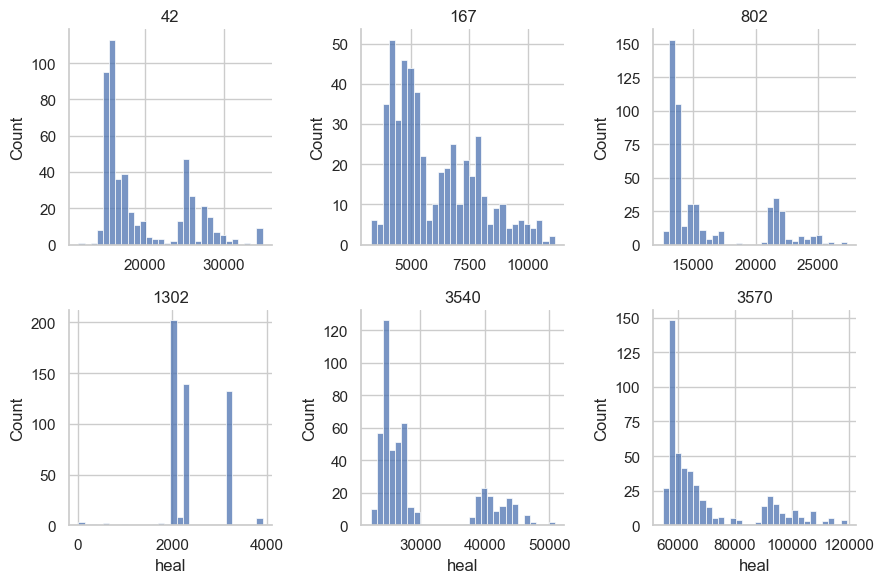

In [9]:
plot_top_histograms(heal, "ability_id", "heal")

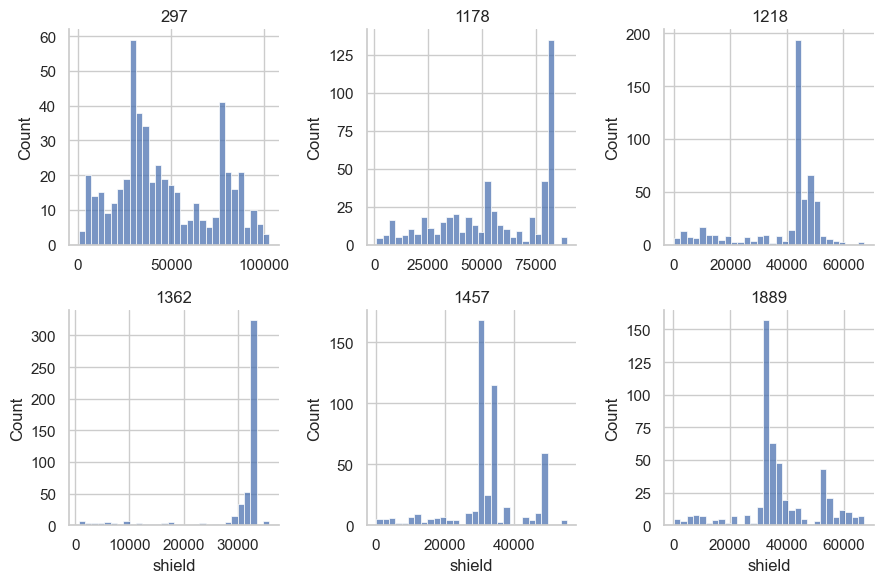

In [13]:
plot_top_histograms(shield, "status_id", "shield")

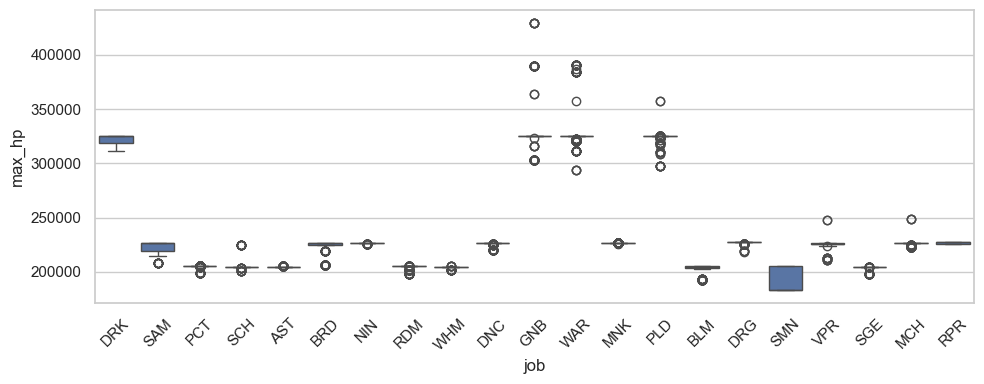

In [10]:
# 各职业最大 HP 分布（通常多峰：不同 iLevel 的玩家）
plt.figure(figsize=(10, 4))
sns.boxplot(data=maxhp, x="job", y="max_hp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. 跨副本对比（可选）

如果拉了多个 encounter 的数据，可以对比同一技能在不同副本的数值。

In [ ]:
all_damage = hb.load_all_encounters()
if all_damage.empty or all_damage['encounter_id'].nunique() < 2:
    print("只有一个 encounter，跳过跨副本对比")
else:
    (all_damage
        .groupby(["ability_id", "encounter_id"])["damage"]
        .median()
        .unstack("encounter_id"))

## 待探索方向

- [ ] 用 `src/data/mitigationActions.ts` / XIVAPI 给 ability_id 加名字
- [ ] 按 iLevel 分桶看 maxHP 多峰
- [ ] 找离群值：`unmitigatedAmount` 异常大的事件可能是解析 bug
- [ ] 验证 reservoir 采样均匀性：对已知分布做 KS 检验
